# QuickCart Stockout Risk Prediction Project

**Name:** Veeralakshmi Gunti

**Project:** QuickCart Stockout Risk Prediction

**Tools Used:**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Datasets

In [3]:
import os

print(os.listdir())

["'jupyter'", '.anaconda', '.cache', '.codex', '.conda', '.copilot', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lemminx', '.m2', '.matplotlib', '.ollama', '.python_history', '.sts4', '.vscode', '.vscode-shared', '3D Objects', 'anaconda3', 'AppData', 'Application Data', 'bingeplay_veeralakshmi.ipynb', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'IBA_IOAPDATA', 'jupyter', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{b7d129df-8dfd-11f1-a5de-9fa7d529baab}.TM.blf', 'NTUSER.DAT{b7d129df-8dfd-11f1-a5de-9fa7d529baab}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{b7d129df-8dfd-11f1-a5de-9fa7d529baab}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'python fundamentals', 'python_fundamentals.ipynb', 'QuickCart_Stockout_Risk_Analysis (2).ipynb', 'Recent', 'ResumeBuilder', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'studentp

## 3. Data Overview

In [5]:
data_path = r"C:\Users\SRINIVAS GUNTI\Downloads\13614778-QuickCart_Stockout_Risk_Project_Spec_(2) (1)\dim_events"

stores = pd.read_csv(data_path + r"\dim_stores.csv")
skus = pd.read_csv(data_path + r"\dim_skus.csv")
suppliers = pd.read_csv(data_path + r"\dim_suppliers.csv")
events = pd.read_csv(data_path + r"\dim_events.csv")
inventory = pd.read_csv(data_path + r"\fact_inventory_daily.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


## 4. Data Validation

In [6]:
print("STORES")
print(stores.shape)
print(stores.columns.tolist())

print("\nSKUS")
print(skus.shape)
print(skus.columns.tolist())

print("\nSUPPLIERS")
print(suppliers.shape)
print(suppliers.columns.tolist())

print("\nEVENTS")
print(events.shape)
print(events.columns.tolist())

print("\nINVENTORY")
print(inventory.shape)
print(inventory.columns.tolist())

STORES
(12, 8)
['store_id', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders']

SKUS
(60, 9)
['sku_id', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id']

SUPPLIERS
(15, 6)
['supplier_id', 'supplier_name', 'categories_supplied', 'reliability_score', 'base_lead_time_days', 'lead_time_variance_days']

EVENTS
(30, 5)
['date', 'event_name', 'event_type', 'demand_multiplier_festive', 'demand_multiplier_other']

INVENTORY
(21600, 16)
['date', 'store_id', 'sku_id', 'supplier_id', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk']


## 5. Data Cleaning

In [7]:
print("===== MISSING VALUES =====")

print("\nSTORES")
print(stores.isnull().sum())

print("\nSKUS")
print(skus.isnull().sum())

print("\nSUPPLIERS")
print(suppliers.isnull().sum())

print("\nEVENTS")
print(events.isnull().sum())

print("\nINVENTORY")
print(inventory.isnull().sum())


print("\n===== DUPLICATES =====")

print("Stores duplicates:", stores.duplicated().sum())
print("SKUs duplicates:", skus.duplicated().sum())
print("Suppliers duplicates:", suppliers.duplicated().sum())
print("Events duplicates:", events.duplicated().sum())
print("Inventory duplicates:", inventory.duplicated().sum())

===== MISSING VALUES =====

STORES
store_id                 0
city                     0
city_display             0
city_tier                0
store_size               0
sqft                     0
opened_year              0
baseline_daily_orders    0
dtype: int64

SKUS
sku_id              0
sku_name            0
category            0
unit_price_inr      0
shelf_life_days     0
is_perishable       0
festive_relevant    0
popularity_tier     0
supplier_id         0
dtype: int64

SUPPLIERS
supplier_id                0
supplier_name              0
categories_supplied        0
reliability_score          3
base_lead_time_days        0
lead_time_variance_days    0
dtype: int64

EVENTS
date                         0
event_name                   0
event_type                   0
demand_multiplier_festive    0
demand_multiplier_other      0
dtype: int64

INVENTORY
date                           0
store_id                       0
sku_id                         0
supplier_id                    0
op

In [8]:
# Check supplier reliability scores
print("Missing reliability scores before cleaning:",
      suppliers["reliability_score"].isna().sum())

# Fill missing values with the median reliability score
suppliers["reliability_score"] = suppliers["reliability_score"].fillna(
    suppliers["reliability_score"].median()
)

print("Missing reliability scores after cleaning:",
      suppliers["reliability_score"].isna().sum())

Missing reliability scores before cleaning: 3
Missing reliability scores after cleaning: 0


In [9]:
print("City display values before cleaning:")
print(stores["city_display"].unique())

# Standardize city display names
stores["city_display"] = stores["city_display"].str.title()

print("\nCity display values after cleaning:")
print(stores["city_display"].unique())

City display values before cleaning:
['Mumbai' 'BENGALURU' 'Bengaluru' 'Delhi' 'Pune' 'hyderabad' 'Hyderabad'
 'Chennai']

City display values after cleaning:
['Mumbai' 'Bengaluru' 'Delhi' 'Pune' 'Hyderabad' 'Chennai']


In [21]:
print(df.columns.tolist())

['date', 'store_id', 'sku_id', 'supplier_id_x', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id_y']


In [11]:
df = inventory.merge(stores, on="store_id")

df = df.merge(
    skus.drop("supplier_id", axis=1),
    on="sku_id"
)

df = df.merge(suppliers, on="supplier_id")

df = df.merge(events, on="date")

df.head()

,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,...,popularity_tier,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0


In [18]:
df.head()

,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,...,popularity_tier,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       21600 non-null  object 
 1   store_id                   21600 non-null  object 
 2   sku_id                     21600 non-null  object 
 3   supplier_id                21600 non-null  object 
 4   opening_stock              21600 non-null  float64
 5   units_demanded             21600 non-null  int64  
 6   units_sold                 21600 non-null  float64
 7   closing_stock              21600 non-null  float64
 8   reorder_point              21600 non-null  float64
 9   reorder_placed             21600 non-null  object 
 10  lead_time_days_expected    21600 non-null  int64  
 11  lead_time_days_actual      1701 non-null   float64
 12  sales_velocity_7d          21600 non-null  float64
 13  days_of_cover              21600 non-null  flo

In [20]:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].min())
print(df["date"].max())

2026-10-01 00:00:00
2026-10-30 00:00:00


In [21]:
print(df["stockout_risk"].value_counts())

print("\nPercentage:")
print(df["stockout_risk"].value_counts(normalize=True) * 100)

stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64

Percentage:
stockout_risk
Safe        65.421296
At-Risk     24.009259
Imminent    10.569444
Name: proportion, dtype: float64


## 7. Target Variable Analysis

The target variable `stockout_risk` represents the stockout risk level of each SKU at each store on a given day.

The three risk classes are:

- Safe
- At-Risk
- Imminent

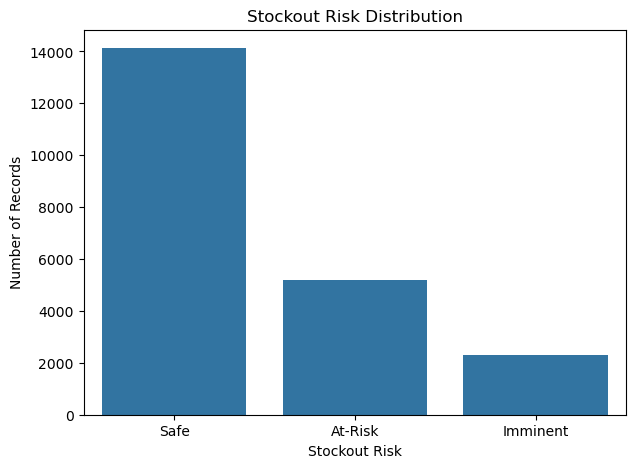

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(x="stockout_risk", data=df)

plt.title("Stockout Risk Distribution")
plt.xlabel("Stockout Risk")
plt.ylabel("Number of Records")

plt.show()

## 8. Date-wise Data Analysis

The dataset contains daily inventory records for each store and SKU combination.

In [24]:
print("Number of unique dates:", df["date"].nunique())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

print("\nRecords per date:")
print(df["date"].value_counts().sort_index())

Number of unique dates: 30

Date range:
2026-10-01 00:00:00 to 2026-10-30 00:00:00

Records per date:
date
2026-10-01    720
2026-10-02    720
2026-10-03    720
2026-10-04    720
2026-10-05    720
2026-10-06    720
2026-10-07    720
2026-10-08    720
2026-10-09    720
2026-10-10    720
2026-10-11    720
2026-10-12    720
2026-10-13    720
2026-10-14    720
2026-10-15    720
2026-10-16    720
2026-10-17    720
2026-10-18    720
2026-10-19    720
2026-10-20    720
2026-10-21    720
2026-10-22    720
2026-10-23    720
2026-10-24    720
2026-10-25    720
2026-10-26    720
2026-10-27    720
2026-10-28    720
2026-10-29    720
2026-10-30    720
Name: count, dtype: int64


## 9. Festival and Event Analysis

This analysis helps to understand how festival periods and special events affect inventory demand and stockout risk.

In [25]:
print("Festival week records:")
print(df["is_festival_week"].value_counts())

print("\nEvent details:")
print(events[["date", "event_name", "event_type"]])

Festival week records:
is_festival_week
N    19944
Y     1656
Name: count, dtype: int64

Event details:
          date          event_name event_type
0   2026-10-01         Regular Day       none
1   2026-10-02         Regular Day       none
2   2026-10-03         Regular Day       none
3   2026-10-04         Regular Day       none
4   2026-10-05         Regular Day       none
5   2026-10-06         Regular Day       none
6   2026-10-07         Regular Day       none
7   2026-10-08         Regular Day       none
8   2026-10-09         Regular Day       none
9   2026-10-10         Regular Day       none
10  2026-10-11  Weekend Flash Sale      promo
11  2026-10-12         Regular Day       none
12  2026-10-13         Regular Day       none
13  2026-10-14         Regular Day       none
14  2026-10-15         Regular Day       none
15  2026-10-16         Regular Day       none
16  2026-10-17         Regular Day       none
17  2026-10-18         Regular Day       none
18  2026-10-19        

## 10. Stockout Risk During Festival Week

This analysis compares stockout risk between festival and non-festival periods.

In [26]:
festival_risk = pd.crosstab(
    df["is_festival_week"],
    df["stockout_risk"],
    normalize="index"
) * 100

print(festival_risk)

stockout_risk       At-Risk   Imminent       Safe
is_festival_week                                 
N                 24.192740   9.511633  66.295628
Y                 21.799517  23.309179  54.891304


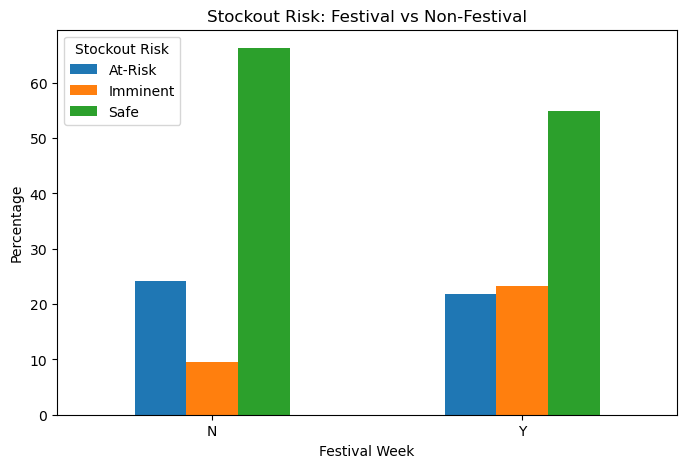

In [27]:
festival_risk.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Stockout Risk: Festival vs Non-Festival")
plt.xlabel("Festival Week")
plt.ylabel("Percentage")

plt.xticks(rotation=0)
plt.legend(title="Stockout Risk")

plt.show()

## 11. Category-wise Stockout Risk

This analysis helps to identify which product categories have higher stockout risk.

In [28]:
category_risk = pd.crosstab(
    df["category"],
    df["stockout_risk"],
    normalize="index"
) * 100

print(category_risk.round(2))

stockout_risk        At-Risk  Imminent   Safe
category                                     
Bakery                 26.34     26.11  47.55
Beverages              22.08     14.55  63.37
Dairy                  14.48      7.54  77.98
Fruits & Vegetables    27.19      7.93  64.88
Home Care              20.60      8.52  70.88
Personal Care          19.17      6.79  74.05
Snacks                 28.98     10.19  60.83
Staples                30.14      5.83  64.03


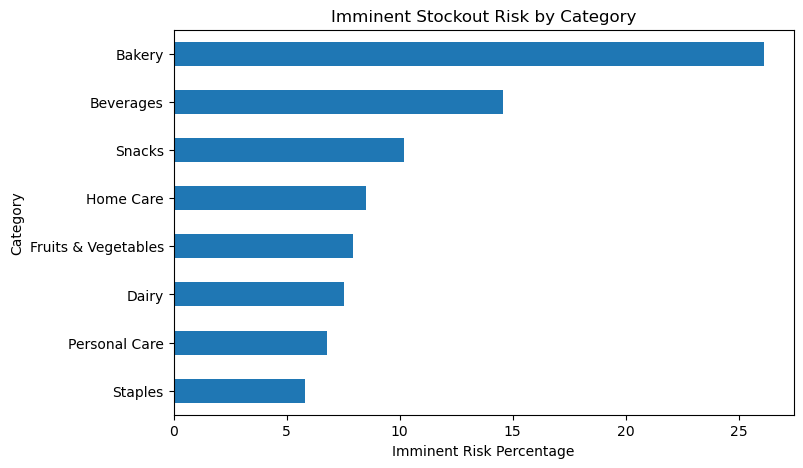

In [29]:
category_risk["Imminent"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Imminent Stockout Risk by Category")
plt.xlabel("Imminent Risk Percentage")
plt.ylabel("Category")

plt.show()

## 12. Supplier Reliability Analysis

This analysis helps to understand how supplier reliability is related to stockout risk.

In [30]:
supplier_risk = pd.crosstab(
    df["reliability_score"],
    df["stockout_risk"],
    normalize="index"
) * 100

print(supplier_risk.round(2))

stockout_risk      At-Risk  Imminent   Safe
reliability_score                          
0.630                26.02     27.04  46.94
0.660                30.28     18.47  51.25
0.670                24.91     15.00  60.09
0.700                15.56      8.03  76.41
0.720                26.11     26.94  46.94
0.725                22.74      7.16  70.10
0.730                19.24     13.40  67.36
0.830                17.57      3.26  79.17
0.910                28.06      2.99  68.96
0.920                46.48      3.52  50.00
0.930                33.39      4.67  61.94


In [31]:
df["reliability_group"] = pd.cut(
    df["reliability_score"],
    bins=[0, 0.75, 0.85, 1],
    labels=["Low", "Medium", "High"]
)

reliability_risk = pd.crosstab(
    df["reliability_group"],
    df["stockout_risk"],
    normalize="index"
) * 100

print(reliability_risk.round(2))

stockout_risk      At-Risk  Imminent   Safe
reliability_group                          
Low                  21.63     13.07  65.30
Medium               17.57      3.26  79.17
High                 34.88      3.82  61.30


## 13. Supplier Reliability vs Stockout Risk

This analysis shows how supplier reliability is related to stockout risk.

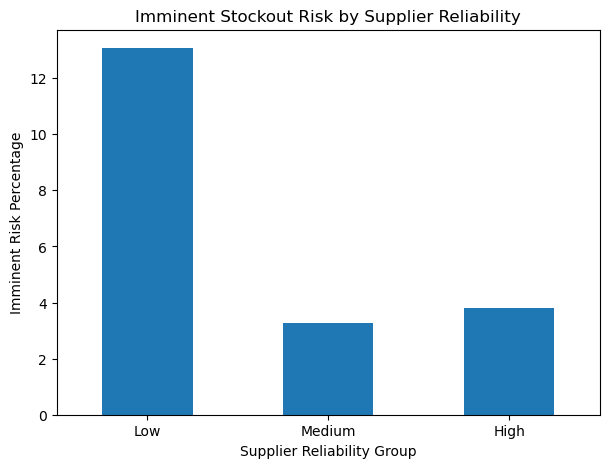

In [32]:
reliability_risk["Imminent"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Imminent Stockout Risk by Supplier Reliability")
plt.xlabel("Supplier Reliability Group")
plt.ylabel("Imminent Risk Percentage")

plt.xticks(rotation=0)

plt.show()

## 14. Feature Engineering

New features are created from the existing data to help the machine learning model identify stockout risk patterns.

In [33]:
df["reorder_gap"] = df["reorder_point"] - df["closing_stock"]

df["days_of_cover_ratio"] = (
    df["days_of_cover"] / df["lead_time_days_expected"]
)

df["day_of_month"] = df["date"].dt.day

print(df[[
    "reorder_gap",
    "days_of_cover_ratio",
    "day_of_month"
]].head())

   reorder_gap  days_of_cover_ratio  day_of_month
0       -108.5                 9.66             1
1        -98.5                10.79             2
2        -83.5                 8.99             3
3        -73.5                 8.79             4
4        -64.5                 8.55             5


## 14.1 Recent Reorder Feature

This feature identifies whether a reorder was placed recently for the same store and SKU.

In [34]:
df = df.sort_values(["store_id", "sku_id", "date"])

df["is_recent_reorder"] = (
    df.groupby(["store_id", "sku_id"])["reorder_placed"]
    .shift(1)
    .fillna("N")
)

print(df[[
    "store_id",
    "sku_id",
    "date",
    "reorder_placed",
    "is_recent_reorder"
]].head(10))

  store_id  sku_id       date reorder_placed is_recent_reorder
0     ST01  SKU001 2026-10-01              N                 N
1     ST01  SKU001 2026-10-02              N                 N
2     ST01  SKU001 2026-10-03              N                 N
3     ST01  SKU001 2026-10-04              N                 N
4     ST01  SKU001 2026-10-05              N                 N
5     ST01  SKU001 2026-10-06              N                 N
6     ST01  SKU001 2026-10-07              N                 N
7     ST01  SKU001 2026-10-08              N                 N
8     ST01  SKU001 2026-10-09              N                 N
9     ST01  SKU001 2026-10-10              N                 N


## 14.2 Category Encoding

The category column is converted into numerical columns so that it can be used by the machine learning models.

In [35]:
df = pd.get_dummies(
    df,
    columns=["category"],
    dtype=int
)

print(df.shape)
print(df.head())

(21600, 51)
        date store_id  sku_id supplier_id  opening_stock  units_demanded  \
0 2026-10-01     ST01  SKU001       SUP11          159.9              15   
1 2026-10-02     ST01  SKU001       SUP11          144.9              10   
2 2026-10-03     ST01  SKU001       SUP11          134.9              15   
3 2026-10-04     ST01  SKU001       SUP11          119.9              10   
4 2026-10-05     ST01  SKU001       SUP11          109.9               9   

   units_sold  closing_stock  reorder_point reorder_placed  ...  day_of_month  \
0        15.0          144.9           36.4              N  ...             1   
1        10.0          134.9           36.4              N  ...             2   
2        15.0          119.9           36.4              N  ...             3   
3        10.0          109.9           36.4              N  ...             4   
4         9.0          100.9           36.4              N  ...             5   

   is_recent_reorder  category_Bakery  categ

## 14.3 Festival Timing Feature

This feature shows the number of days from the start of the festival week.

In [36]:
festival_start = pd.Timestamp("2026-10-22")

df["days_since_festival_start"] = (
    df["date"] - festival_start
).dt.days

print(df[[
    "date",
    "is_festival_week",
    "days_since_festival_start"
]].head())

        date is_festival_week  days_since_festival_start
0 2026-10-01                N                        -21
1 2026-10-02                N                        -20
2 2026-10-03                N                        -19
3 2026-10-04                N                        -18
4 2026-10-05                N                        -17


## 15. Train-Test Split

The data is split based on date. Earlier dates are used for training and later dates are used for testing.

In [37]:
train = df[df["date"] <= "2026-10-23"].copy()

test = df[df["date"] >= "2026-10-24"].copy()

print("Training data:", train.shape)
print("Testing data:", test.shape)

print("\nTraining dates:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting dates:")
print(test["date"].min(), "to", test["date"].max())

Training data: (16560, 52)
Testing data: (5040, 52)

Training dates:
2026-10-01 00:00:00 to 2026-10-23 00:00:00

Testing dates:
2026-10-24 00:00:00 to 2026-10-30 00:00:00


## 16. Baseline Model

A baseline model is created by predicting the most common stockout risk class for all test records.

This gives us a simple benchmark to compare with the machine learning models.

In [38]:
baseline_prediction = train["stockout_risk"].mode()[0]

print("Baseline prediction:", baseline_prediction)

baseline_accuracy = (
    test["stockout_risk"] == baseline_prediction
).mean()

print("Baseline Accuracy:", baseline_accuracy)

Baseline prediction: Safe
Baseline Accuracy: 0.6228174603174603


## 17. Logistic Regression

Logistic Regression is used as the first machine learning classification model to predict stockout risk.

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

### 17.1 Prepare Features and Target

The input features and target variable are separated before training the Logistic Regression model.

In [62]:
features = [
    "reorder_gap",
    "days_of_cover_ratio",
    "reliability_score",
    "day_of_month",
    "days_since_festival_start",
    "is_festival_week"
]

features = features + [
    "category_Bakery",
    "category_Beverages",
    "category_Dairy",
    "category_Fruits & Vegetables",
    "category_Home Care",
    "category_Personal Care",
    "category_Snacks",
    "category_Staples"
]

X_train = train[features]
y_train = train["stockout_risk"]

X_test = test[features]
y_test = test["stockout_risk"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16560, 14)
X_test: (5040, 14)
y_train: (16560,)
y_test: (5040,)


### 17.2 Feature Scaling

StandardScaler is used to bring the numerical features to a similar scale before training the Logistic Regression model.

In [63]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train["is_festival_week"] = X_train["is_festival_week"].map({"N": 0, "Y": 1})
X_test["is_festival_week"] = X_test["is_festival_week"].map({"N": 0, "Y": 1})

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


### 17.3 Train Logistic Regression Model

The Logistic Regression model is trained using the scaled training data.

In [64]:
print("Missing values in training features:")
print(X_train.isna().sum())

Missing values in training features:
reorder_gap                     0
days_of_cover_ratio             0
reliability_score               0
day_of_month                    0
days_since_festival_start       0
is_festival_week                0
category_Bakery                 0
category_Beverages              0
category_Dairy                  0
category_Fruits & Vegetables    0
category_Home Care              0
category_Personal Care          0
category_Snacks                 0
category_Staples                0
dtype: int64


In [65]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train["reliability_score"] = X_train["reliability_score"].fillna(
    X_train["reliability_score"].median()
)

X_test["reliability_score"] = X_test["reliability_score"].fillna(
    X_train["reliability_score"].median()
)

print("Missing values after cleaning:")
print(X_train.isna().sum().sum())
print(X_test.isna().sum().sum())

Missing values after cleaning:
0
0


In [66]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [67]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [68]:
logistic_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, logistic_predictions))

print("\nClassification Report:")
print(classification_report(y_test, logistic_predictions))

Logistic Regression Accuracy: 0.8509920634920635

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.69      0.60      0.64      1126
    Imminent       0.87      0.71      0.78       775
        Safe       0.89      0.98      0.93      3139

    accuracy                           0.85      5040
   macro avg       0.82      0.76      0.79      5040
weighted avg       0.84      0.85      0.84      5040



## 18. Random Forest

Random Forest is used as another classification model to predict stockout risk.

It can capture non-linear relationships between inventory features and stockout risk.

In [69]:
from sklearn.ensemble import RandomForestClassifier

In [70]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [71]:
random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, random_forest_predictions))

print("\nClassification Report:")
print(classification_report(y_test, random_forest_predictions))

Random Forest Accuracy: 0.9236111111111112

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.84      0.82      0.83      1126
    Imminent       0.86      0.78      0.82       775
        Safe       0.97      1.00      0.98      3139

    accuracy                           0.92      5040
   macro avg       0.89      0.86      0.88      5040
weighted avg       0.92      0.92      0.92      5040



## 19. Model Comparison

The Logistic Regression and Random Forest models are compared based on accuracy and Imminent class recall.

In [72]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.8510, 0.9236],
    "Imminent Recall": [0.71, 0.78]
})

print(model_comparison)

                 Model  Accuracy  Imminent Recall
0  Logistic Regression    0.8510             0.71
1        Random Forest    0.9236             0.78


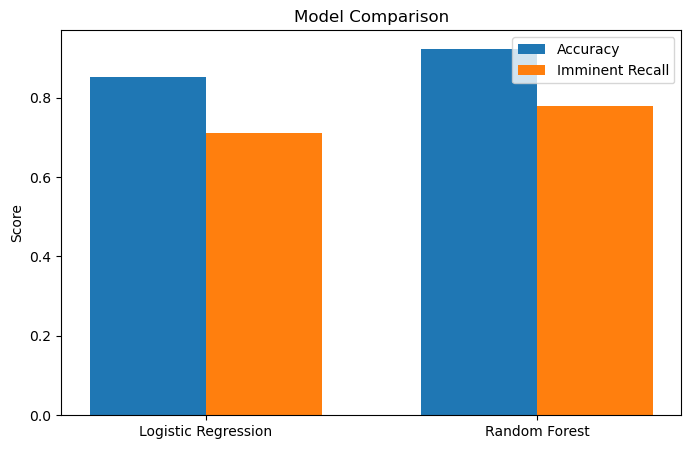

In [73]:
plt.figure(figsize=(8, 5))

x = np.arange(len(model_comparison["Model"]))
width = 0.35

plt.bar(x - width/2, model_comparison["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, model_comparison["Imminent Recall"], width, label="Imminent Recall")

plt.xticks(x, model_comparison["Model"])
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.show()

## 20. Random Forest Feature Importance

Feature importance is used to identify which features have the most influence on the Random Forest predictions.

In [74]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_
})


feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

                         Feature  Importance
1            days_of_cover_ratio    0.440712
0                    reorder_gap    0.391036
2              reliability_score    0.060691
3                   day_of_month    0.030922
4      days_since_festival_start    0.029625
8                 category_Dairy    0.008783
13              category_Staples    0.008530
9   category_Fruits & Vegetables    0.005228
7             category_Beverages    0.005038
6                category_Bakery    0.004760
10            category_Home Care    0.004707
12               category_Snacks    0.004372
11        category_Personal Care    0.003810
5               is_festival_week    0.001784


## 20.1 Feature Importance Visualization

The feature importance values are visualized to understand which features contribute most to the Random Forest model.

<Figure size 800x600 with 0 Axes>

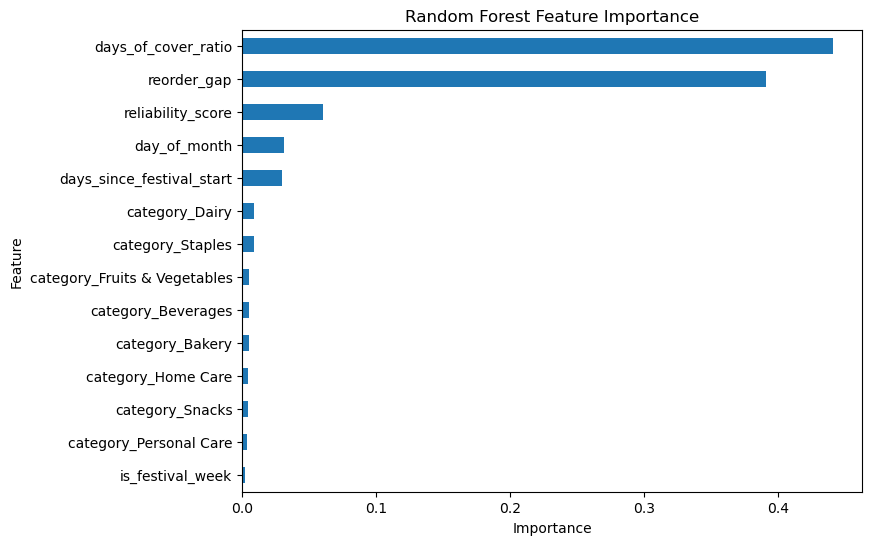

In [75]:
plt.figure(figsize=(8, 6))

feature_importance.sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 21. Business Insights

Based on the data analysis and machine learning results, the following business insights were identified:

- Random Forest performed better than Logistic Regression with 92.36% accuracy.
- The recall for the Imminent class was 78%, which is important for identifying potential stockouts.
- `days_of_cover_ratio` is the most important feature.
- `reorder_gap` is the second most important feature.
- Supplier reliability also affects stockout risk.
- Festival periods have higher Imminent stockout risk than non-festival periods.
- Products with low inventory coverage should be monitored closely.
- Timely reordering can help reduce the risk of stockouts.

## 22. Conclusion

This project developed a machine learning approach to predict daily stockout risk for QuickCart inventory.

The data was cleaned, integrated, and analyzed to identify important factors affecting stockout risk. Features such as `days_of_cover_ratio`, `reorder_gap`, supplier reliability, and festival timing were used for prediction.

Two classification models were evaluated: Logistic Regression and Random Forest. Random Forest performed better with an accuracy of 92.36% and 78% recall for the Imminent class.

The results show that machine learning can help QuickCart identify high-risk inventory items early and support timely replenishment decisions.